✅ PROJECT_ROOT: c:\Users\максим\workvs\compare_competencies
✅ sys.path обновлён

Загружено навыков с весами: 55
Загружено маппингов компетенций: 44

Профили студентов (навыки после маппинга):
  base: 87 навыков
  dc: 98 навыков
  top_dc: 174 навыков

🚀 Запуск gap-анализа (TF-IDF)...

--- BASE ---
  Компетенций: 31
  Навыков (после маппинга): 87
  Покрытие (weighted): 12.84%
  Дефицитов высокого спроса: 10

--- DC ---
  Компетенций: 38
  Навыков (после маппинга): 98
  Покрытие (weighted): 15.0%
  Дефицитов высокого спроса: 10

--- TOP_DC ---
  Компетенций: 54
  Навыков (после маппинга): 174
  Покрытие (weighted): 16.33%
  Дефицитов высокого спроса: 10

📊 Генерация графиков...


C:\Users\максим\AppData\Local\Temp\ipykernel_17456\2688045262.py:164: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\максим\AppData\Local\Temp\ipykernel_17456\2688045262.py:165: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig(RESULTS_DIR / "summary_comparison.png", dpi=300, bbox_inches='tight')


C:\Users\максим\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


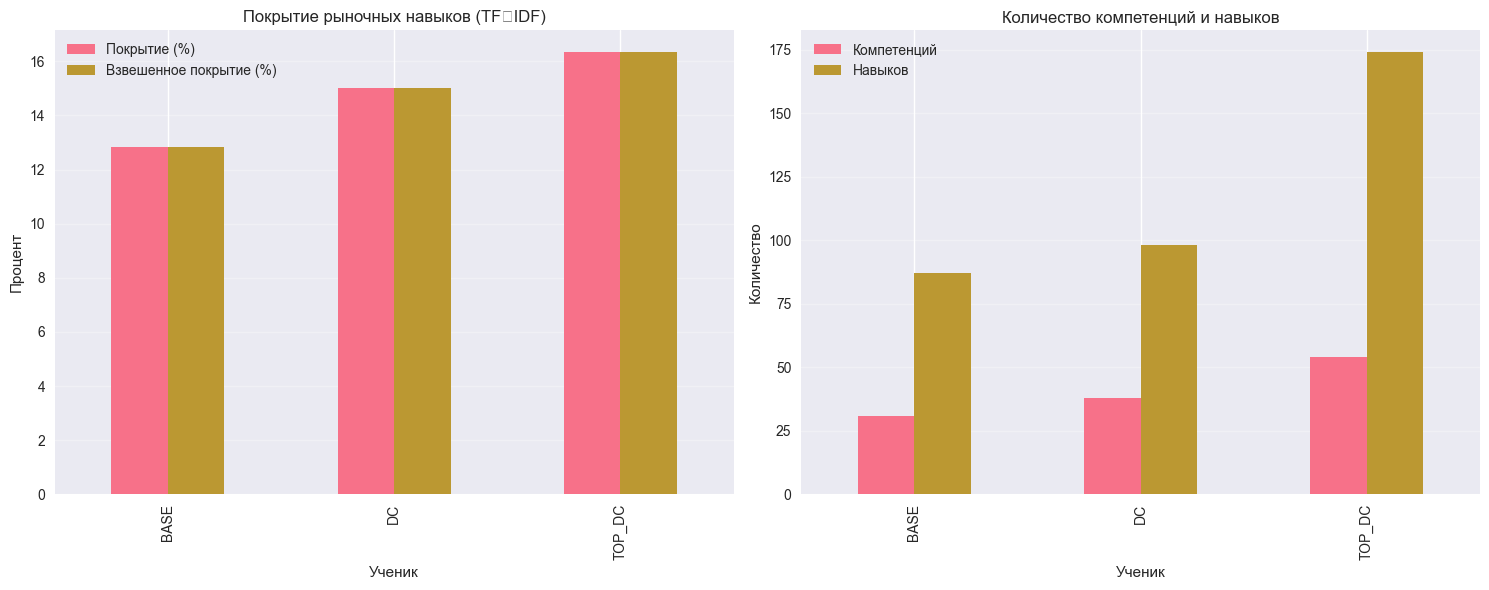


✅ Анализ успешно завершён!
Результаты сохранены в: c:\Users\максим\workvs\compare_competencies\data\result


In [1]:
# 02_competency_matching.py — версия с TF-IDF

import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.student import StudentProfile

print(f"✅ PROJECT_ROOT: {PROJECT_ROOT}")
print(f"✅ sys.path обновлён\n")

# ---------------------- ПУТИ ----------------------
DATA_DIR = PROJECT_ROOT / "data"
MAPPING_PATH = DATA_DIR / "processed" / "competency_mapping.json"
WEIGHTS_PATH = DATA_DIR / "processed" / "skill_weights.json"   # новый файл
RESULTS_DIR = DATA_DIR / "result"
STUDENTS_DIR = DATA_DIR / "students"

for profile in ["base", "dc", "top_dc"]:
    (RESULTS_DIR / profile).mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)

# ---------------------- ЗАГРУЗКА ----------------------
with open(MAPPING_PATH, encoding='utf-8') as f:
    mapping = json.load(f)

with open(WEIGHTS_PATH, encoding='utf-8') as f:
    skill_weights = json.load(f)   # {skill: weight}

print(f"Загружено навыков с весами: {len(skill_weights)}")
print(f"Загружено маппингов компетенций: {len(mapping)}\n")

# ---------------------- ПРЕОБРАЗОВАНИЕ СТУДЕНТОВ ----------------------
def get_student_skills(competency_codes):
    """Преобразует коды компетенций в навыки через маппинг."""
    skills = set()
    for code in competency_codes:
        code_clean = code.strip('. ').upper()
        if code_clean in mapping:
            skills.update(mapping[code_clean])
        elif code.strip('.') in mapping:
            skills.update(mapping[code.strip('.')])
    return list(skills)

def load_student_codes(profile_name):
    path = STUDENTS_DIR / f"{profile_name}_competency.json"
    if not path.exists():
        path = STUDENTS_DIR / f"{profile_name}.json"
    try:
        with open(path, encoding='utf-8') as f:
            data = json.load(f)
        return data.get("компетенции") or data.get("навыки") or data.get("codes") or []
    except Exception as e:
        print(f"⚠️ Не удалось загрузить {profile_name}: {e}")
        return []

students_data = {
    name: get_student_skills(load_student_codes(name))
    for name in ["base", "dc", "top_dc"]
}

print("Профили студентов (навыки после маппинга):")
for name, skills in students_data.items():
    print(f"  {name}: {len(skills)} навыков")

# ---------------------- АНАЛИЗ ----------------------
print("\n🚀 Запуск gap-анализа (TF-IDF)...\n")

total_weight = sum(skill_weights.values())
results = {}

for name, student_skills in students_data.items():
    # Покрытие (weighted)
    covered_weight = sum(skill_weights.get(s, 0) for s in student_skills if s in skill_weights)
    coverage_pct = (covered_weight / total_weight * 100) if total_weight else 0.0

    # Дефициты
    missing = []
    for skill, weight in skill_weights.items():
        if skill not in student_skills:
            missing.append({"skill": skill, "weight": weight, "frequency": int(weight * 100)})

    missing_sorted = sorted(missing, key=lambda x: x["weight"], reverse=True)
    high_gaps = missing_sorted[:10]   # условно считаем высоким приоритетом топ-10
    medium_gaps = missing_sorted[10:20]

    # Собираем отчёт
    report = {
        "student_name": name.upper(),
        "total_competencies": len(load_student_codes(name)),  # исходное количество кодов
        "total_mapped_skills": len(student_skills),
        "coverage_percent": round(coverage_pct, 2),
        "weighted_coverage_percent": round(coverage_pct, 2),  # здесь одно и то же
        "covered_skills": student_skills,
        "high_demand_gaps": [{"skill": g["skill"], "frequency": g["frequency"]} for g in high_gaps],
        "medium_demand_gaps": [{"skill": g["skill"], "frequency": g["frequency"]} for g in medium_gaps],
        "low_demand_gaps": [],
        "recommendations": [
            f"Приоритет №1: освоить {', '.join([g['skill'] for g in high_gaps[:3]])} (высокий спрос на рынке)."
        ] if high_gaps else []
    }

    results[name] = report

    # Сохраняем JSON
    student_dir = RESULTS_DIR / name
    with open(student_dir / f"comparison_report_{name}.json", "w", encoding="utf-8") as f:
        json.dump(report, f, ensure_ascii=False, indent=2)

    # Сохраняем рекомендации
    recommendations = {
        "student": name,
        "high_priority": [g["skill"] for g in high_gaps[:10]],
        "medium_priority": [g["skill"] for g in medium_gaps[:8]],
        "suggestion": report["recommendations"][0] if report["recommendations"] else "Рекомендуется изучить востребованные навыки."
    }
    with open(student_dir / f"recommendations_{name}.json", "w", encoding="utf-8") as f:
        json.dump(recommendations, f, ensure_ascii=False, indent=2)

    print(f"--- {name.upper()} ---")
    print(f"  Компетенций: {report['total_competencies']}")
    print(f"  Навыков (после маппинга): {report['total_mapped_skills']}")
    print(f"  Покрытие (weighted): {report['coverage_percent']}%")
    print(f"  Дефицитов высокого спроса: {len(high_gaps)}\n")

# ---------------------- ВИЗУАЛИЗАЦИЯ ----------------------
print("📊 Генерация графиков...")

data = []
for name, rep in results.items():
    data.append({
        "Ученик": name.upper(),
        "Компетенций": rep["total_competencies"],
        "Навыков": rep["total_mapped_skills"],
        "Покрытие (%)": rep["coverage_percent"],
        "Взвешенное покрытие (%)": rep["weighted_coverage_percent"]
    })

df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df.plot(x="Ученик", y=["Покрытие (%)", "Взвешенное покрытие (%)"], kind="bar", ax=axes[0])
axes[0].set_title("Покрытие рыночных навыков (TF‑IDF)")
axes[0].set_ylabel("Процент")
axes[0].grid(axis='y', alpha=0.3)

df.plot(x="Ученик", y=["Компетенций", "Навыков"], kind="bar", ax=axes[1])
axes[1].set_title("Количество компетенций и навыков")
axes[1].set_ylabel("Количество")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "summary_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Графики топ-дефицитов
for name, rep in results.items():
    high_gaps = rep["high_demand_gaps"][:10]
    if not high_gaps:
        continue

    skills = [g["skill"] for g in high_gaps]
    freqs = [g["frequency"] for g in high_gaps]

    plt.figure(figsize=(10, 6))
    plt.barh(skills, freqs, color='salmon')
    plt.title(f"Топ-10 дефицитов высокого спроса — {name.upper()}")
    plt.xlabel("Условная частота (weight*100)")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / name / f"high_demand_deficits_{name}.png", dpi=300, bbox_inches='tight')
    plt.close()

print("\n✅ Анализ успешно завершён!")
print(f"Результаты сохранены в: {RESULTS_DIR}")